# AgroSmart KZ: графиктер және модель метрикалары

Бұл notebook `results/metrics.json` файлын оқып, модель сапасын график түрінде көрсетеді.

Онда:
- классификация метрикалары,
- confusion matrix,
- calibration curve,
- forecast actual vs predicted графиктері,
- бірнеше график түрінің мысалы бар.

## 1. Импорттау және кітапханаларды орнату

Бұл бөлімде қажет кітапханаларды импорттаймыз және графиктердің Jupyter ішінде дұрыс шығуын баптаймыз.

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Greens")
%matplotlib inline

metrics_path = Path("results") / "metrics.json"
print(f"Metrics file: {metrics_path.resolve()}")

Metrics file: D:\AgroSmart-KZ\results\metrics.json


## 2. Деректерді дайындау

`metrics.json` файлын оқып, графиктер үшін кестелік форматқа келтіреміз.

In [2]:
with metrics_path.open("r", encoding="utf-8") as f:
    metrics = json.load(f)

classification = metrics.get("classification", {})
forecasting = metrics.get("forecasting", {})

metrics_df = pd.DataFrame(
    {
        "Metric": ["ROC-AUC", "PR-AUC", "F1", "Precision", "Recall", "Brier Score"],
        "Value": [
            classification.get("metrics", {}).get("roc_auc"),
            classification.get("metrics", {}).get("pr_auc"),
            classification.get("metrics", {}).get("f1"),
            classification.get("metrics", {}).get("precision"),
            classification.get("metrics", {}).get("recall"),
            classification.get("metrics", {}).get("brier_score"),
        ],
    }
)

metrics_df

,Metric,Value
0,ROC-AUC,0.776644
1,PR-AUC,0.902919
2,F1,0.895409
3,Precision,0.824760
4,Recall,0.979296
5,Brier Score,0.139846


## 3. Қарапайым график салу

Негізгі классификация метрикаларын bar chart ретінде көрсетеміз.

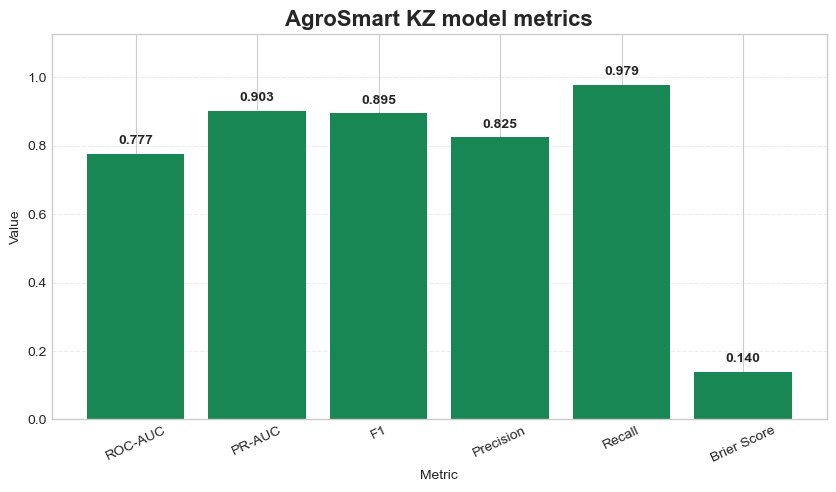

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = metrics_df.copy()
plot_df["Value"] = pd.to_numeric(plot_df["Value"], errors="coerce")
plot_df = plot_df.dropna(subset=["Value"])

bars = ax.bar(plot_df["Metric"], plot_df["Value"], color="#198754")
ax.set_title("AgroSmart KZ model metrics", fontsize=16, fontweight="bold")
ax.set_xlabel("Metric")
ax.set_ylabel("Value")
ax.set_ylim(0, max(1.0, plot_df["Value"].max() * 1.15))
ax.grid(axis="y", linestyle="--", alpha=0.35)
ax.tick_params(axis="x", rotation=25)

for bar, value in zip(bars, plot_df["Value"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

plt.show()

## 4. Графикті безендіру

Төменде confusion matrix және calibration curve көрсетіледі.

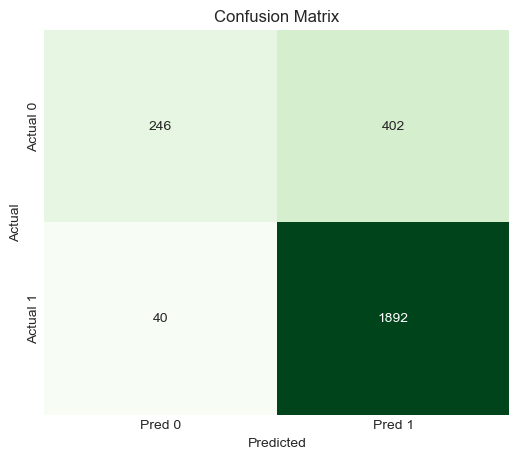

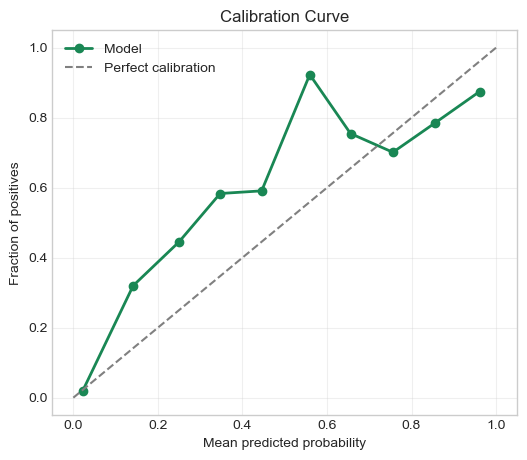

In [4]:
cm = classification.get("metrics", {}).get("confusion_matrix", [[0, 0], [0, 0]])
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax)
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.show()

calibration = classification.get("metrics", {}).get("calibration_curve", [])
if calibration:
    cal_df = pd.DataFrame(calibration)
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(cal_df["mean_predicted_prob"], cal_df["fraction_of_positives"], marker="o", linewidth=2, color="#198754", label="Model")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
    ax.set_title("Calibration Curve")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
else:
    print("Calibration data is not available.")

## 5. Бірнеше график түрін көрсету

Forecast нәтижелерін line, bar және scatter түрінде салыстырамыз.

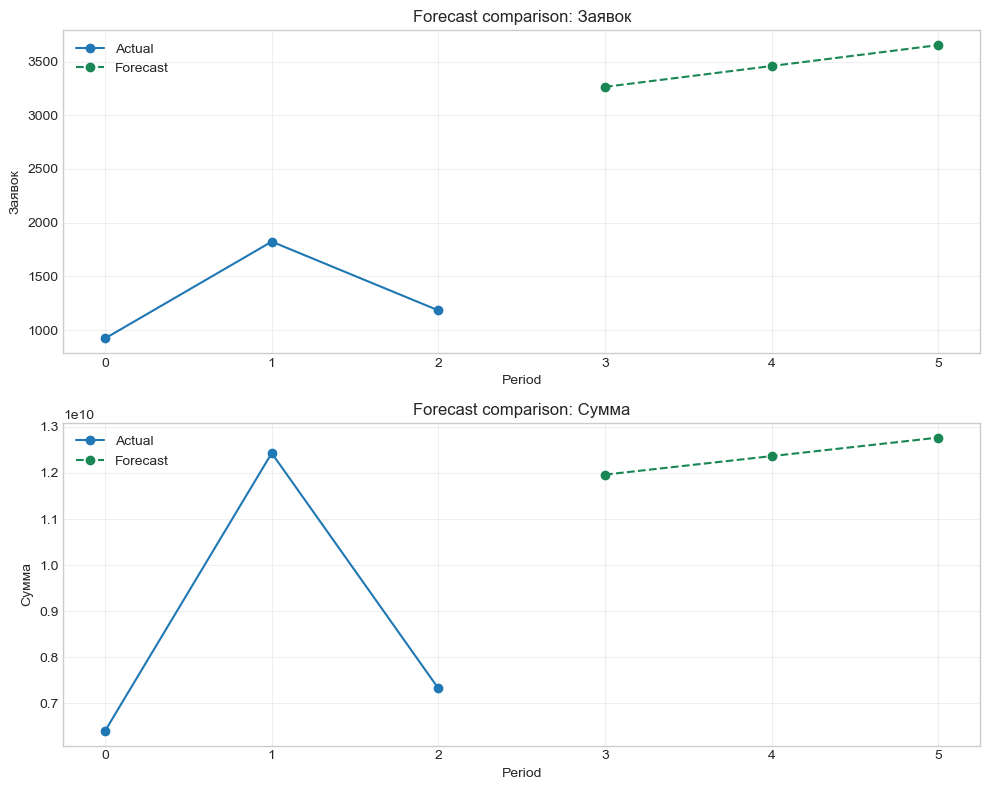

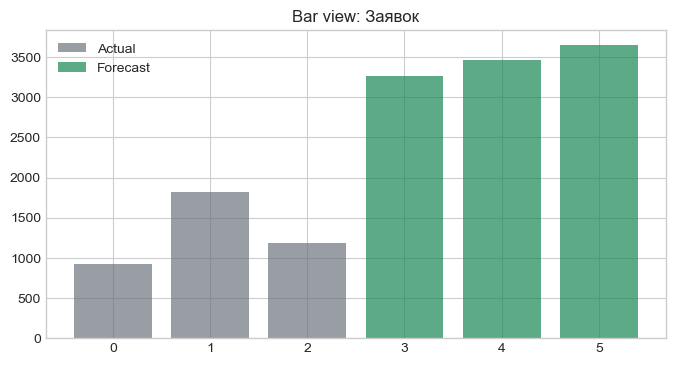

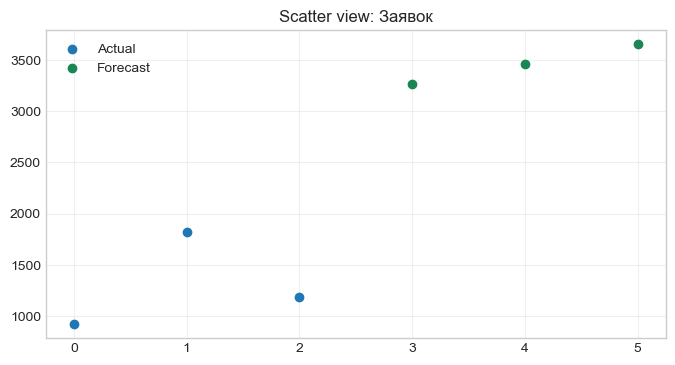

In [5]:
forecast_sections = []
for key in ["Заявок", "Сумма"]:
    section = forecasting.get(key)
    if isinstance(section, dict) and section.get("actual") and section.get("forecast"):
        forecast_sections.append((key, section))

fig, axes = plt.subplots(len(forecast_sections), 1, figsize=(10, 4 * max(1, len(forecast_sections))))
if len(forecast_sections) == 1:
    axes = [axes]

for ax, (key, section) in zip(axes, forecast_sections):
    actual = section["actual"]
    forecast = section["forecast"]
    x_actual = np.arange(len(actual))
    x_forecast = np.arange(len(actual), len(actual) + len(forecast))

    ax.plot(x_actual, actual, marker="o", label="Actual", color="#1f77b4")
    ax.plot(x_forecast, forecast, marker="o", linestyle="--", label="Forecast", color="#198754")
    ax.set_title(f"Forecast comparison: {key}")
    ax.set_xlabel("Period")
    ax.set_ylabel(key)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
if forecast_sections:
    key, section = forecast_sections[0]
    actual = section["actual"]
    forecast = section["forecast"]
    ax.bar(np.arange(len(actual)), actual, alpha=0.7, label="Actual", color="#6c757d")
    ax.bar(np.arange(len(forecast)) + len(actual), forecast, alpha=0.7, label="Forecast", color="#198754")
    ax.set_title(f"Bar view: {key}")
    ax.legend()
    plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
if forecast_sections:
    key, section = forecast_sections[0]
    actual = section["actual"]
    forecast = section["forecast"]
    ax.scatter(np.arange(len(actual)), actual, label="Actual", color="#1f77b4")
    ax.scatter(np.arange(len(actual), len(actual) + len(forecast)), forecast, label="Forecast", color="#198754")
    ax.set_title(f"Scatter view: {key}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()

## 6. Графикті сақтау

Нәтиже PNG немесе PDF ретінде сақталады.

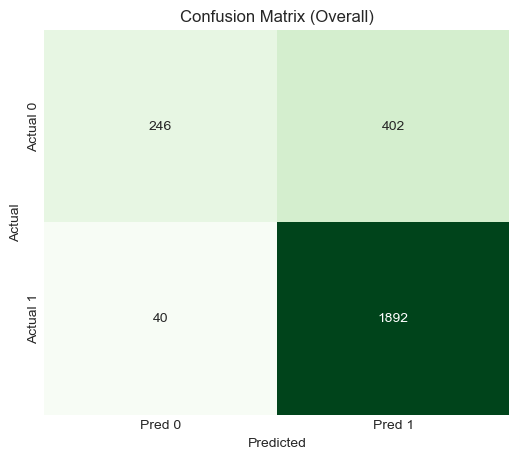

In [7]:
# Overall confusion matrix (use overall if available, else fall back to test confusion matrix)
cm_overall = classification.get("metrics", {}).get("confusion_matrix_overall")
if cm_overall is None:
    # fallback to existing confusion matrix stored under classification.metrics.confusion_matrix
    cm_overall = classification.get("metrics", {}).get("confusion_matrix")

if cm_overall is None:
    print("Overall confusion matrix not found in results/metrics.json.")
else:
    import numpy as _np
    cm_df = pd.DataFrame(cm_overall, index=["Actual 0", "Actual 1"], columns=["Pred 0", "Pred 1"])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax)
    ax.set_title("Confusion Matrix (Overall)")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.show()

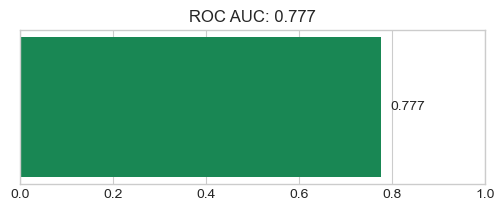

: 

In [ ]:
# ROC curve plotting: uses stored curve points if available, otherwise shows ROC-AUC as a simple bar
roc_curve = classification.get("metrics", {}).get("roc_curve") or classification.get("metrics", {}).get("roc")
if roc_curve and isinstance(roc_curve, dict) and 'fpr' in roc_curve and 'tpr' in roc_curve:
    fpr = np.array(roc_curve['fpr'])
    tpr = np.array(roc_curve['tpr'])
    auc_val = classification.get("metrics", {}).get("roc_auc")
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(fpr, tpr, color="#198754", linewidth=2, label=f"ROC (AUC={auc_val:.3f})" if auc_val else "ROC")
    ax.plot([0, 1], [0, 1], linestyle="--", color="gray")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.show()
else:
    auc_val = classification.get("metrics", {}).get("roc_auc")
    if auc_val is None:
        print("ROC curve data not available in results/metrics.json.")
    else:
        fig, ax = plt.subplots(figsize=(6, 2))
        ax.barh([0], [auc_val], color="#198754")
        ax.set_xlim(0, 1)
        ax.set_yticks([])
        ax.set_title(f"ROC AUC: {auc_val:.3f}")
        ax.text(auc_val + 0.02, 0, f"{auc_val:.3f}", va="center")
        plt.show()

In [6]:
output_dir = Path("results")
output_dir.mkdir(exist_ok=True)

# Save the last created figure if available
fig_path_png = output_dir / "metrics_dashboard.png"
fig_path_pdf = output_dir / "metrics_dashboard.pdf"

plt.savefig(fig_path_png, dpi=200, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")

print(f"Saved: {fig_path_png}")
print(f"Saved: {fig_path_pdf}")

Saved: results\metrics_dashboard.png
Saved: results\metrics_dashboard.pdf


<Figure size 640x480 with 0 Axes>